**VIX in the one-factor Bergomi model**

# Imports

In [1]:
# TODO: try to calibrate the single case model to VIX data

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
from bergomi import OneFactorBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import xi0_heston, relative_error

sns.set_theme(context="talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
COLORS = sns.color_palette("tab10")

In [131]:
mats = {"1M": 1.0 / 12.0, "3M": 3.0 / 12.0, "6M": 6.0 / 12.0, "1Y": 1.0}

# Single case

## VIX implied volatility

In [135]:
# model parameters
params = {"w": 5.0, "k": 20}

rho = -0.7
# xi0 = lambda u: np.ones_like(u) * 0.235**2
xi0 = lambda t: xi0_heston(t, shape="backwardation")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params)

In [136]:
onebergomi.w

5.0

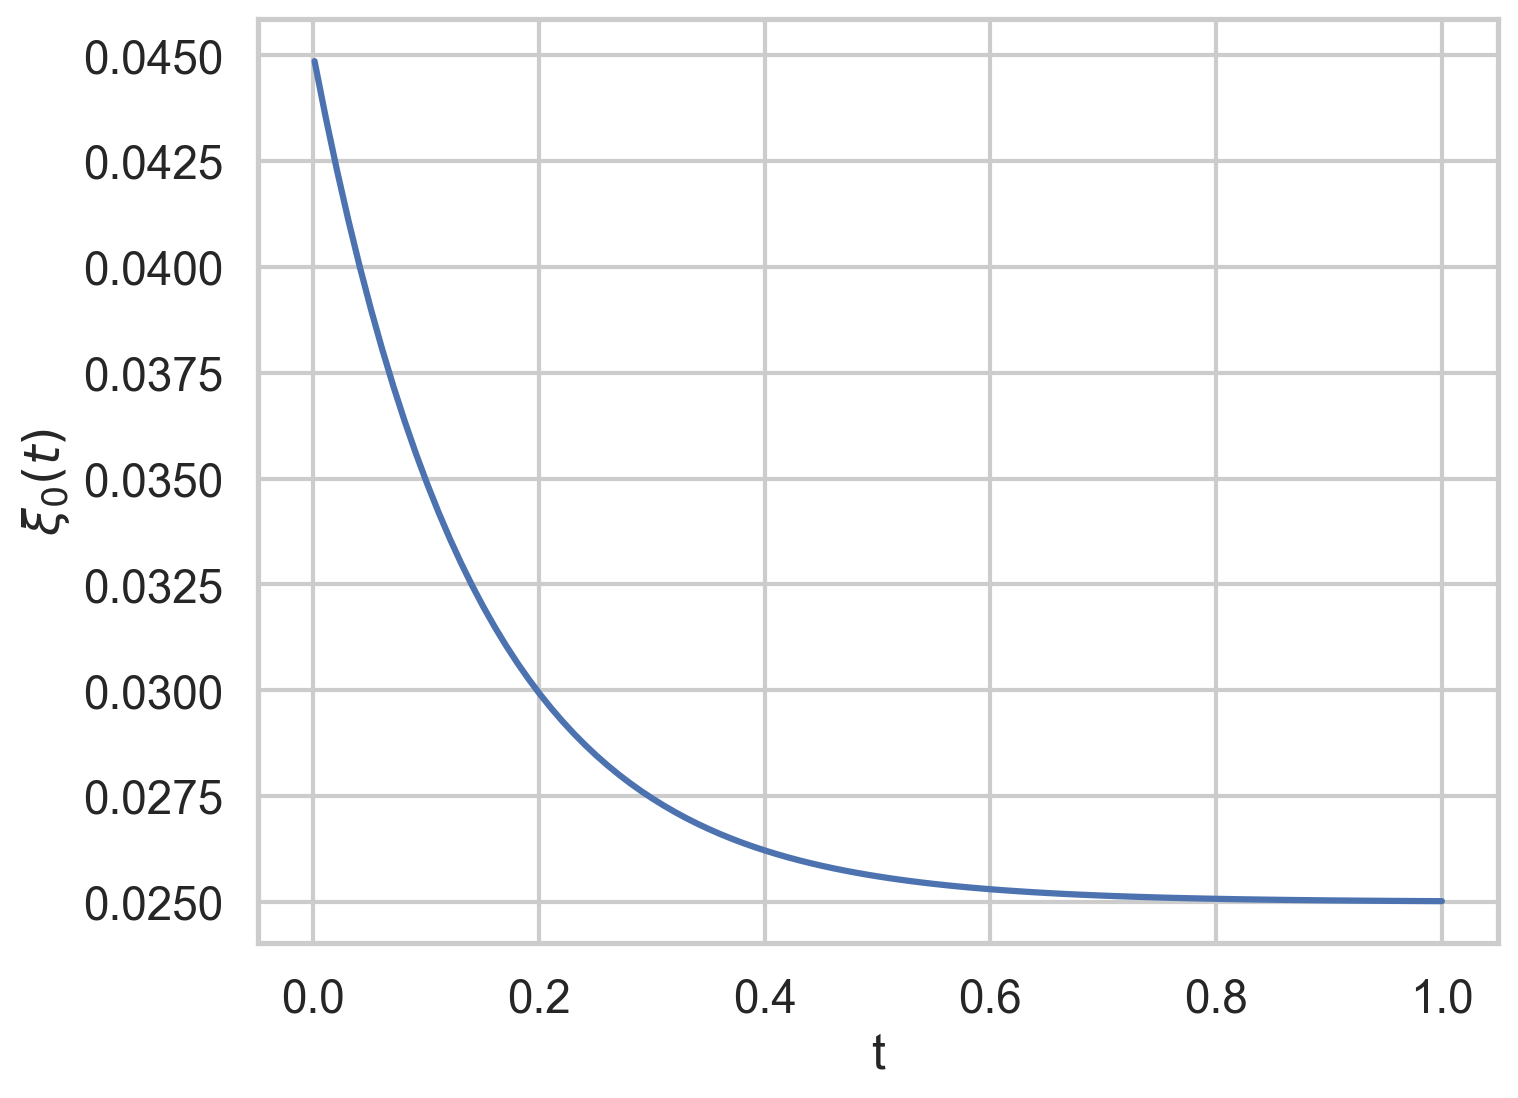

In [137]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, onebergomi.xi0(ts))
ax.set_xlabel("t")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [138]:
# log moneyness
ks = np.linspace(-0.1, 0.5, 11)

In [139]:
# VIX implied volatilities via quadrature
n_quad = 80
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad)
    for month, T in mats.items()
}
impvol_vix

{'1M': array([0.63973494, 0.6482143 , 0.6568224 , 0.66527225, 0.67362405,
        0.68193637, 0.69018669, 0.69803618, 0.70541389, 0.71368866,
        0.71925931]),
 '3M': array([0.3712599 , 0.3762053 , 0.38128302, 0.38625643, 0.3911607 ,
        0.39605066, 0.40095732, 0.40547803, 0.41000262, 0.41465178,
        0.41868284]),
 '6M': array([0.26092555, 0.26444141, 0.26802126, 0.27153637, 0.2750231 ,
        0.27849291, 0.28193887, 0.2852257 , 0.28831255, 0.29177506,
        0.2942327 ])}

In [140]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: onebergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [141]:
impvol_vix_approx

{'1M': array([0.63680634, 0.64610109, 0.65498605, 0.66361889, 0.67201331,
        0.6800659 , 0.68759248, 0.6943728 , 0.70020571, 0.70495561,
        0.70857629]),
 '3M': array([0.36938064, 0.3748668 , 0.38010634, 0.3851945 , 0.39014094,
        0.39488621, 0.39932273, 0.40332146, 0.40676408, 0.40957026,
        0.41171275]),
 '6M': array([0.25958125, 0.26346479, 0.26717205, 0.27077165, 0.27426999,
        0.27762424, 0.28075676, 0.28357502, 0.28599497, 0.28796051,
        0.2894536 ])}

In [142]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: onebergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

In [143]:
impvol_vix_expansion

{'1M': array([0.6407917 , 0.64946212, 0.65813253, 0.66680295, 0.67547336,
        0.68414378, 0.69281419, 0.70148461, 0.71015503, 0.71882544,
        0.72749586]),
 '3M': array([0.37176792, 0.37687621, 0.3819845 , 0.38709279, 0.39220108,
        0.39730937, 0.40241766, 0.40752595, 0.41263424, 0.41774253,
        0.42285082]),
 '6M': array([0.26125806, 0.26487225, 0.26848644, 0.27210063, 0.27571482,
        0.27932901, 0.2829432 , 0.28655739, 0.29017158, 0.29378576,
        0.29739995])}

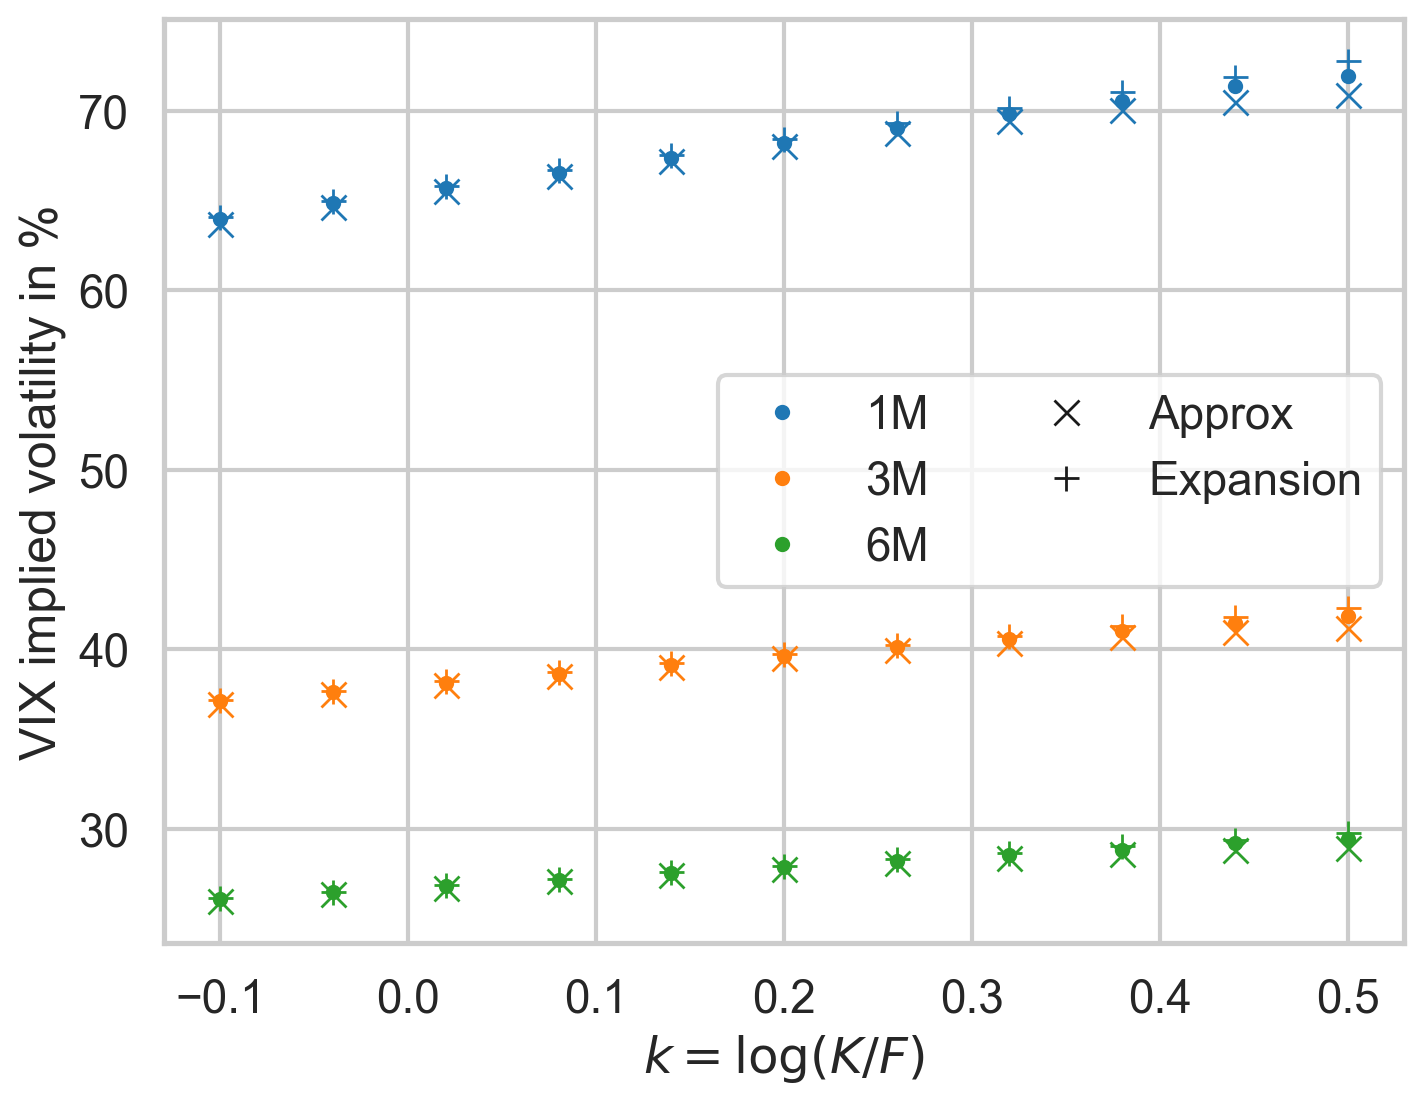

In [144]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 100 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 100 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 100 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(loc="best", ncol=2)
# ax.set_ylim(80, 100)
plt.show()

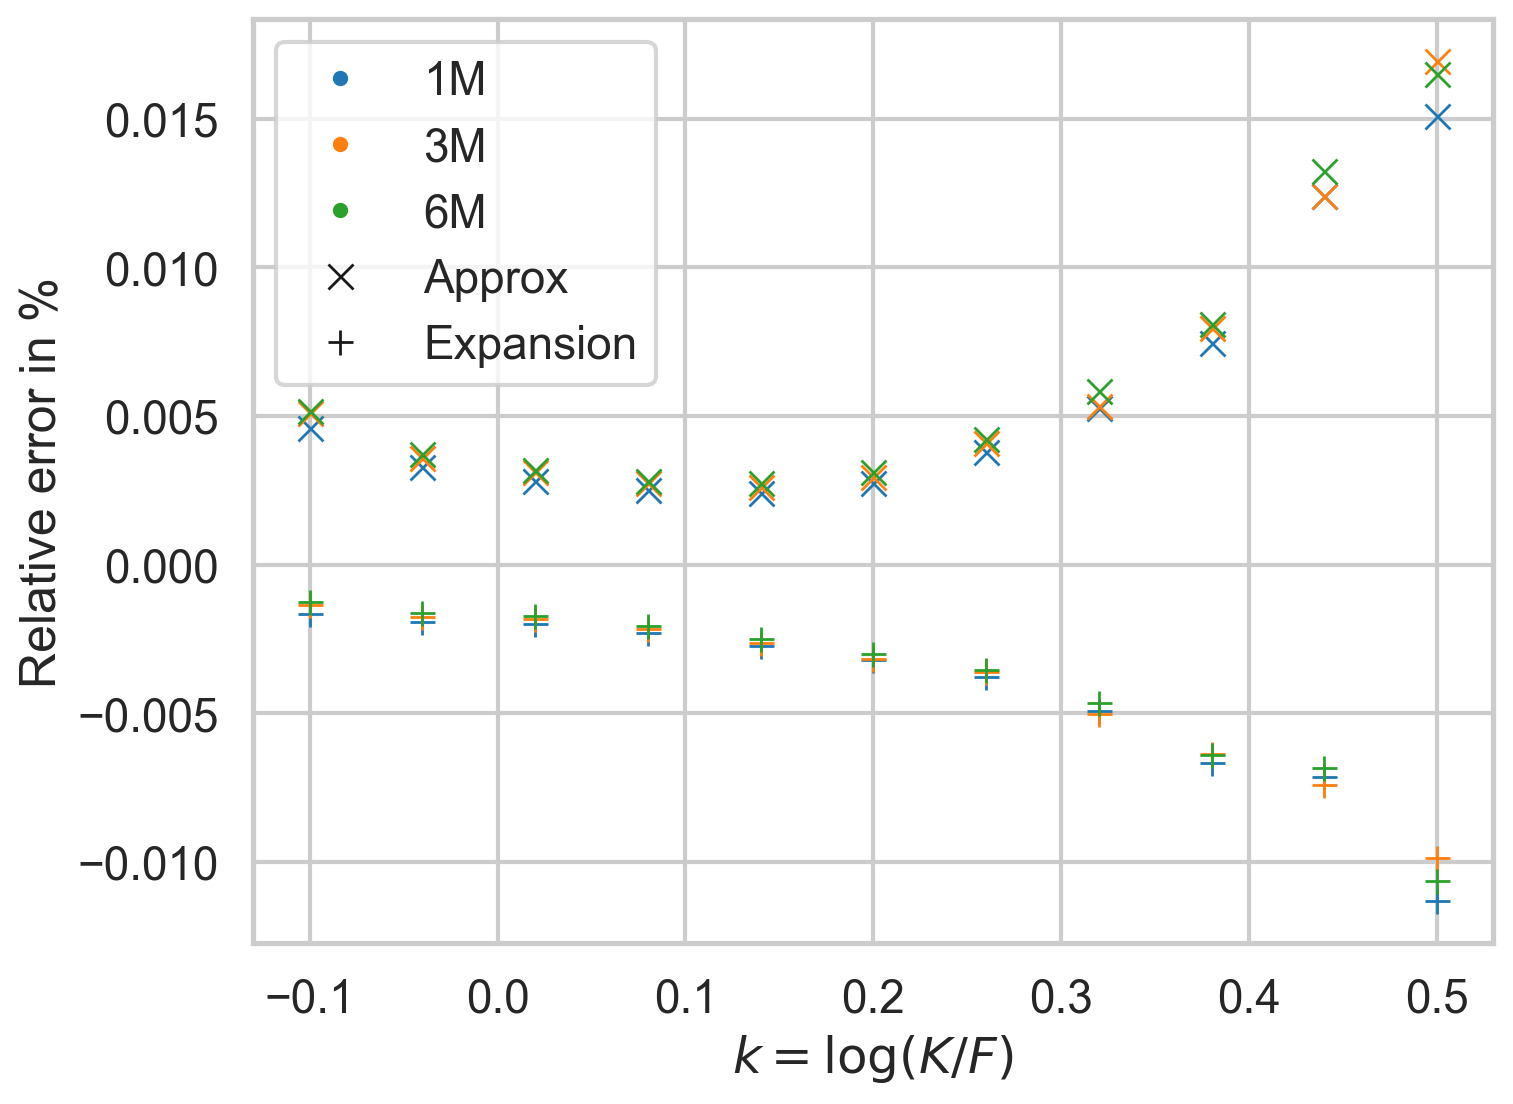

In [145]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_approx[month], impvol_vix[month]) for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_expansion[month], impvol_vix[month]) for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error in %")
ax.legend(loc="best")
# ax.set_ylim(-1e-3, 1e-3)
plt.show()

# Mixed case

In [132]:
params = {"w": 3.0, "k": 1.0}

rho = -0.7
xi0 = lambda u: np.ones_like(u) * 0.235**2
# xi0 = lambda t: xi0_heston(t, shape="contango")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params)

lbd = 0.3
w_2 = 0.6
ks = np.linspace(-0.2, 0.5, 11)

In [133]:
# VIX implied volatilities
n_quad = 120
impvol_vix_mixed = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad, lbd=lbd, w_2=w_2)
    for month, T in mats.items()
}

In [134]:
# Gauss quadrature
# check for higher-order, is the integration range really correct? B seems different.
impvol_vix_mixed_approx = {
    month: np.asarray(
        onebergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0, n_quad=n_quad
        )
    )
    for month, T in mats.items()
}

In [162]:
# Hermite series
impvol_vix_mixed_approx_series = {
    month: np.asarray(
        onebergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=3, n_trunc_herm=4
        )
    )
    for month, T in mats.items()
}

In [203]:
# maybe adjust formula depending on call/put and sigma_1 / sigma_2

implied_vol_vix_expansion = {
    month: np.array(
        [
            onebergomi.implied_vol_vix_expansion_mixed(
                k=k, T=T, lbd=lbd, volvol_2=w_2, n_trunc_herm=3
            )
            for k in ks
        ]
    )
    for month, T in mats.items()
}

sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 0.7974736667265856
sigp_2 0.15949473334531714
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
sigp_1 1.2767085260896094
sigp_2 0.2553417052179219
s

In [204]:
# # Lognormal approximation
# impvol_vix_mixed_approx_lognorm = {
#     month: np.asarray(
#         onebergomi.implied_vol_vix_lognorm_approx_mixed(
#             lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
#         )
#     )
#     for month, T in mats.items()
# }

In [205]:
# # Shifted Lognormal approximation
# impvol_vix_mixed_approx_slognorm = {
#     month: np.asarray(
#         onebergomi.implied_vol_vix_shifted_lognorm_approx_mixed(
#             lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
#         )
#     )
#     for month, T in mats.items()
# }

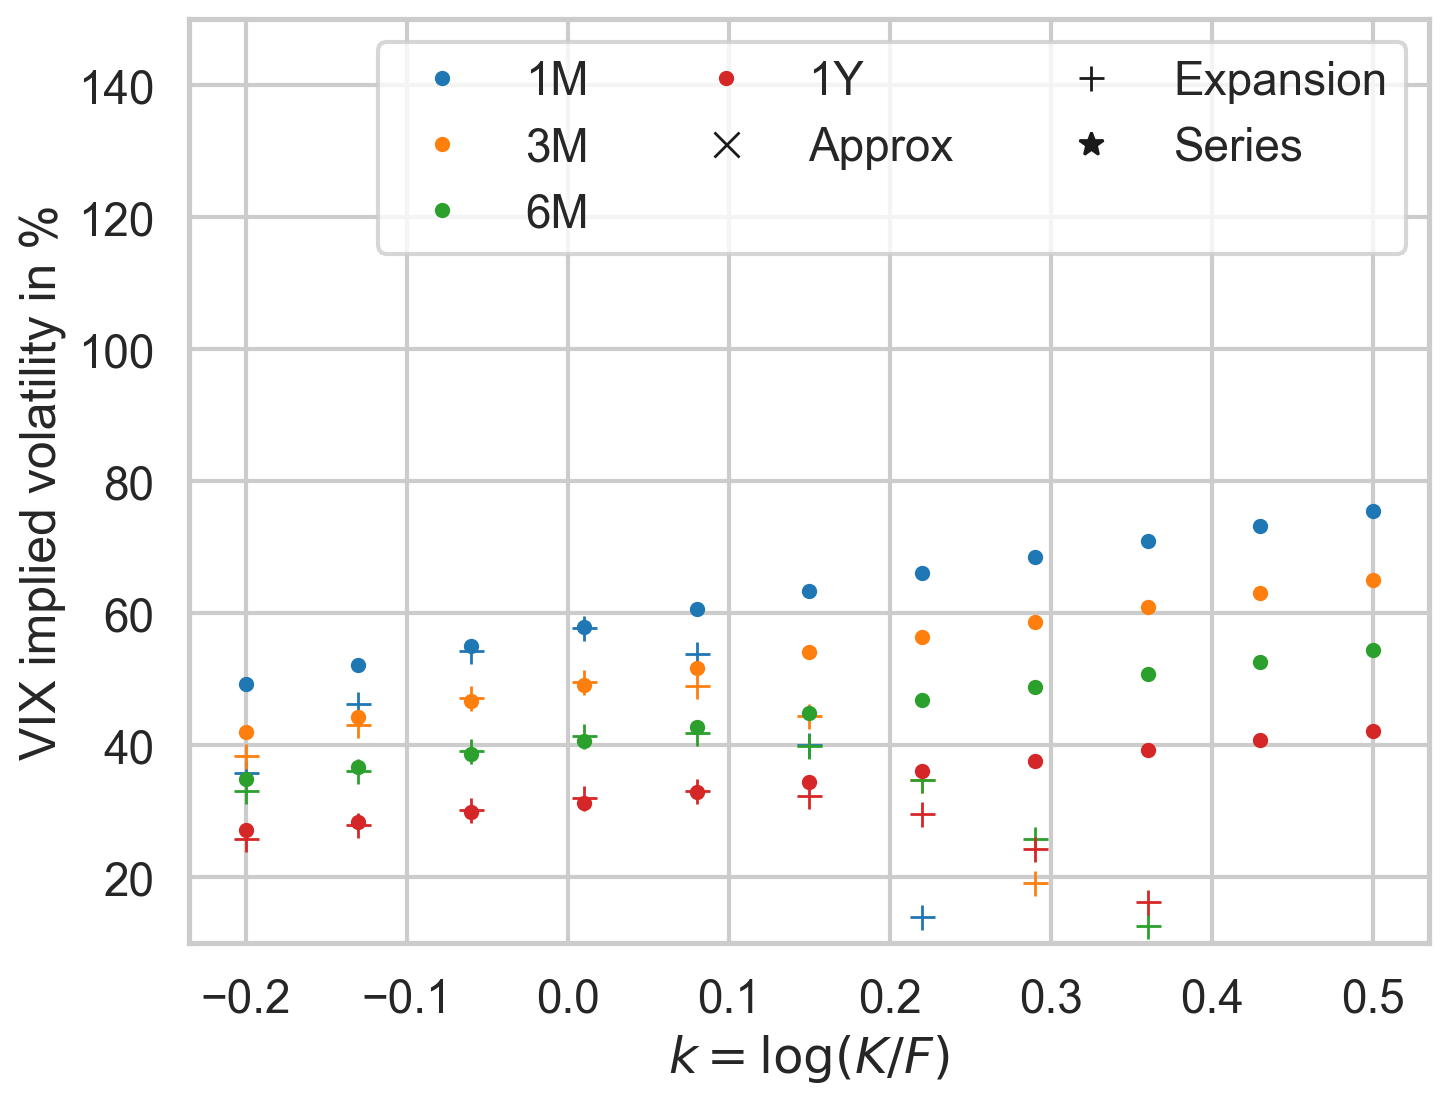

In [206]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, month in enumerate(mats.keys()):
    ax.plot(
        ks,
        100 * impvol_vix_mixed[month],
        ".",
        color=COLORS[i],
        label=f"{month}",
    )
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx[month],
    #     "x",
    #     color=COLORS[i],
    # )
    ax.plot(
        ks,
        100 * implied_vol_vix_expansion[month],
        "+",
        color=COLORS[i],
    )
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_lognorm[month],
    #     "v",
    #     color=COLORS[i],
    # )
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_slognorm[month],
    #     "*",
    #     color=COLORS[i],
    # )
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_series[month],
    #     "*",
    #     color=COLORS[i],
    # )
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.plot([], [], "k*", label="Series")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(ncol=3)
ax.set_ylim(10, 150)
plt.show()

In [105]:
impvol_vix_mixed_approx_series

{'1M': array([0.54937579, 0.55050455, 0.55219196, 0.55330999, 0.55544384,
        0.55763073, 0.55986859, 0.56215502, 0.5644875 , 0.56686349,
        0.56927986]),
 '3M': array([0.45719542, 0.45839258, 0.45983262, 0.46037592, 0.46211131,
        0.4638917 , 0.4657156 , 0.46758138, 0.46948694, 0.4714302 ,
        0.47340892]),
 '6M': array([0.36601923, 0.36699779, 0.36814295, 0.3684295 , 0.36980055,
        0.37120782, 0.37265055, 0.37412725, 0.37563644, 0.37717648,
        0.37874557])}

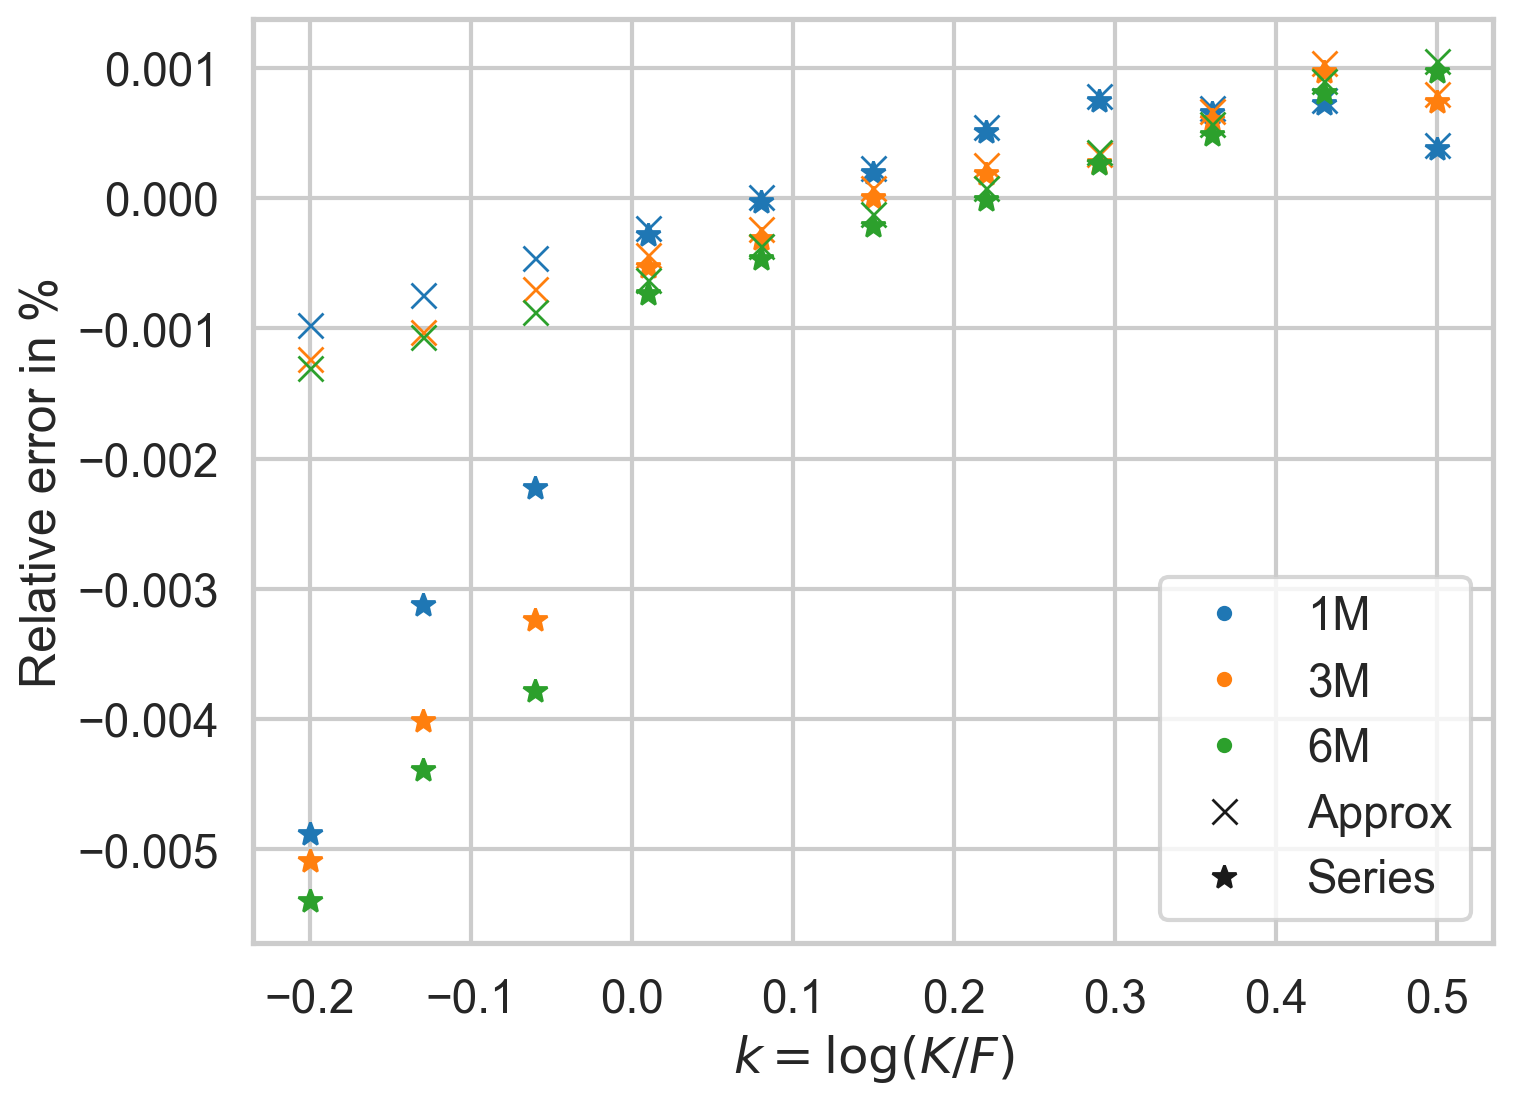

In [106]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_mixed_approx[month], impvol_vix_mixed[month])
    for month in mats
]
rel_error_approx_series = [
    relative_error(impvol_vix_mixed_approx_series[month], impvol_vix_mixed[month])
    for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_approx_series[i], "*", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k*", label="Series")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error in %")
ax.legend(loc="best")
# ax.set_ylim(-1e-3, 1e-3)
plt.show()